# Two-cell overlap relaxation (analytic)

This notebook uses `potentials.py` to reproduce the **repulsion-driven relaxation** of two initially overlapping cells.

**Test setup (from the article description):**
- Two identical cells of radius $r = 5u m$
- Initial center-to-center distance $d_0 = 9u m$
- Cell *touching* distance is $R = r_1 + r_2 = 10u m$
- Therefore the cells start with **10% overlap** (since $d_0 = 0.9R$)

We assume motion is **overdamped** (velocity proportional to force) and that only **repulsion** acts while $d < R$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import the local potentials implementation
from potentials import CellInteractionSimulation

In [2]:
# --- Problem parameters ---
r = 5.0  # um
d0 = 9.0 # um (initial center-to-center distance)

# Instantiate the potentials helper and align it with the test
sim = CellInteractionSimulation(
    potential_model='original',
    r_default=r,
    # Use repulsion/adhesion strengths similar to PhysiCell defaults unless you want to override
    c1_repulsion=10.0, c2_repulsion=10.0,
    c1_adhesion=0.0, c2_adhesion=0.0,  # repulsion-only for the analytic relaxation
    c1_relative_maximum_adhesion_distance=1.25,
    c2_relative_maximum_adhesion_distance=1.25,
)

R = sim.R  # touching distance = r1 + r2
c_rep = sim.effective_repulsion
R, c_rep

(10.0, np.float64(10.0))

## Force law and analytic solution

In `potentials.py`, the original repulsion term (for $d e R$) is

$$F(d) = c_{rep}(1 - d/R)^2, quad d e R,$$

and $F(d)=0$ for $d>R$ (repulsion switches off once cells no longer overlap).

For an overdamped 1D symmetric pair, if each cell’s speed is proportional to the force magnitude, we can write

$$ot d(t) = rac{2}{amma}F(d(t)) = K(1 - d/R)^2, uad K = rac{2 c_{rep}}{amma},$$

where $amma$ is an effective drag/friction coefficient (units set the time scale).

Let $u(t) = 1 - d(t)/R$. Then $d = R(1-u)$ and $ot d = -Rot u$. The ODE becomes

$$-Rot u = K u^2 ightarrow ot u = -rac{K}{R}u^2.$$

With $u(0)=u_0=1-d_0/R$, the solution is

$$u(t)=rac{u_0}{1 + (K u_0/R)t},$$

and therefore the **analytic separation curve** is

$$d(t)=Rig(1-rac{u_0}{1+eta t}ig),quad eta = rac{K u_0}{R} = rac{2 c_{rep}}{amma R}u_0.$$

As $t	onfty$, $d(t)	o R$ (cells approach just-touching, overlap goes to zero).

In [3]:
# --- Analytic separation curve ---
gamma = 1.0  # effective drag (sets time scale); adjust to match a specific simulator
K = 2.0 * c_rep / gamma
u0 = 1.0 - d0 / R
beta = (K * u0) / R

t_end = 50.0
t = np.linspace(0.0, t_end, 1001)
d_analytic = R * (1.0 - (u0 / (1.0 + beta * t)))
overlap_analytic = np.maximum(0.0, R - d_analytic)

d_analytic[:5], overlap_analytic[:5], (R, d0, u0, beta)

(array([9.        , 9.00990099, 9.01960784, 9.02912621, 9.03846154]),
 array([1.        , 0.99009901, 0.98039216, 0.97087379, 0.96153846]),
 (10.0, 9.0, 0.09999999999999998, np.float64(0.19999999999999996)))

In [4]:
# --- Numerical integration using the same force law (sanity check) ---
def repulsion_force_magnitude_from_potentials(distance_um: float) -> float:
    # Use potentials.py to compute the repulsive term temp_r directly
    _, temp_r, _ = sim.cell_interaction_potential(distance_um, div_d_flag=True)
    return float(temp_r)

dt = 0.01
steps = int(t_end / dt)
t_num = np.linspace(0.0, t_end, steps + 1)
d_num = np.zeros(steps + 1)
d_num[0] = d0

for n in range(steps):
    d = d_num[n]
    F = repulsion_force_magnitude_from_potentials(d) if d < R else 0.0
    d_dot = (2.0 / gamma) * F
    d_next = d + dt * d_dot
    d_num[n + 1] = min(d_next, R)  # clamp at touching distance once overlap is gone

overlap_num = np.maximum(0.0, R - d_num)
d_num[:5], overlap_num[:5]

(array([9.        , 9.002     , 9.00399201, 9.00597607, 9.00795224]),
 array([1.        , 0.998     , 0.99600799, 0.99402393, 0.99204776]))

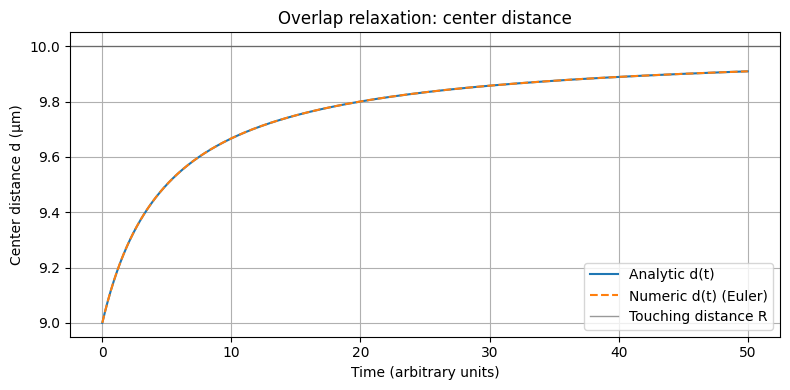

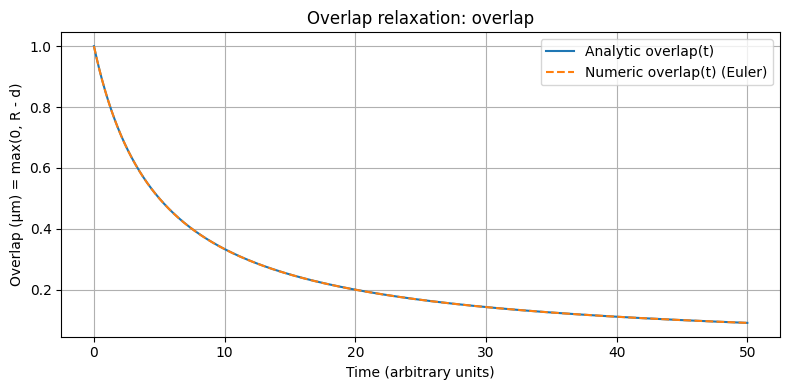

In [5]:
# --- Plot: separation and overlap vs time ---
plt.figure(figsize=(8, 4))
plt.plot(t, d_analytic, label='Analytic d(t)')
plt.plot(t_num, d_num, '--', label='Numeric d(t) (Euler)')
plt.axhline(R, color='k', linewidth=1, alpha=0.4, label='Touching distance R')
plt.xlabel('Time (arbitrary units)')
plt.ylabel('Center distance d (µm)')
plt.title('Overlap relaxation: center distance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, overlap_analytic, label='Analytic overlap(t)')
plt.plot(t_num, overlap_num, '--', label='Numeric overlap(t) (Euler)')
plt.xlabel('Time (arbitrary units)')
plt.ylabel('Overlap (µm) = max(0, R - d)')
plt.title('Overlap relaxation: overlap')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

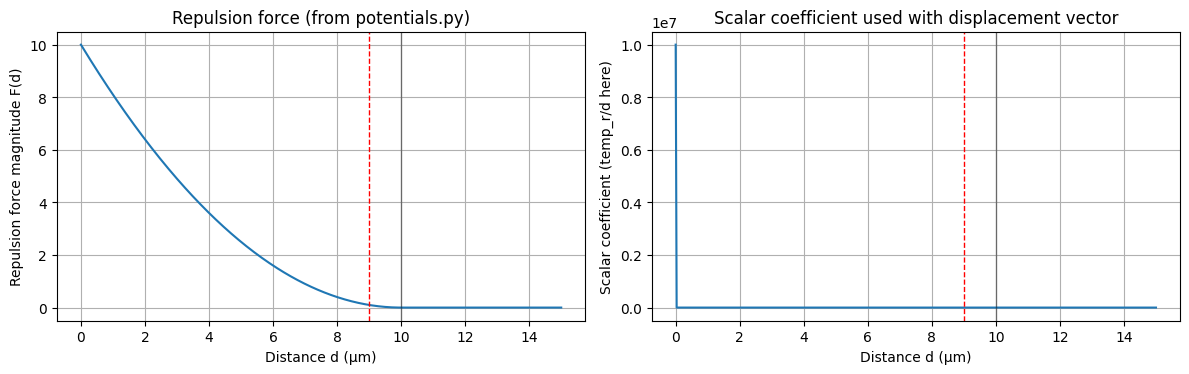

In [6]:
# --- Plot: force and potential proxy vs distance ---
d_vals = np.linspace(0.0, 1.5 * R, 500)
F_vals = np.array([repulsion_force_magnitude_from_potentials(di) if di > 0 else repulsion_force_magnitude_from_potentials(1e-6) for di in d_vals])

# potentials.py returns (temp_r - temp_a)/d when div_d_flag=True; here adhesion=0 so this is temp_r/d
V_proxy = []
for di in d_vals:
    if di <= 0:
        di = 1e-6
    total_potential, _, _ = sim.cell_interaction_potential(di, div_d_flag=True)
    V_proxy.append(float(total_potential))
V_proxy = np.array(V_proxy)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(d_vals, F_vals)
ax[0].axvline(R, color='k', linewidth=1, alpha=0.4)
ax[0].axvline(d0, color='r', linestyle='--', linewidth=1)
ax[0].set_xlabel('Distance d (µm)')
ax[0].set_ylabel('Repulsion force magnitude F(d)')
ax[0].set_title('Repulsion force (from potentials.py)')
ax[0].grid(True)

ax[1].plot(d_vals, V_proxy)
ax[1].axvline(R, color='k', linewidth=1, alpha=0.4)
ax[1].axvline(d0, color='r', linestyle='--', linewidth=1)
ax[1].set_xlabel('Distance d (µm)')
ax[1].set_ylabel('Scalar coefficient (temp_r/d here)')
ax[1].set_title('Scalar coefficient used with displacement vector')
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Notes / how to match a specific simulator

- The **shape** of $d(t)$ is fixed by the repulsion law. The **time scale** is set by $amma$ (drag).
- To match a particular PhysiCell run, tune `gamma` so that the analytic curve reaches (near) $R$ at the same time as in the simulation.
- If you include adhesion (nonzero `c*_adhesion`) the ODE changes (and you may not have a simple closed form).